Loaded reference:
  x shape = (513,)
  t shape = (201,)
  u_ref shape = (201, 513)
  u_ref min/max = -1.0 0.9918149256349341

Parameter counts:
  Sto-SQP theta size = 1981
  Det-SQP theta size = 1981

Full-grid metrics:
Sto-SQP              MSE = 4.296415e-06   relL2 = 2.935224e-03
Deterministic SQP    MSE = 3.537522e-05   relL2 = 8.422435e-03

Error color scale:
  vmin = 1e-08
  vmax = 0.08297971592809616

Saved figure -> allen_cahn_reference_plus_sto_det_errors.png
Saved figure -> allen_cahn_reference_plus_sto_det_errors.pdf


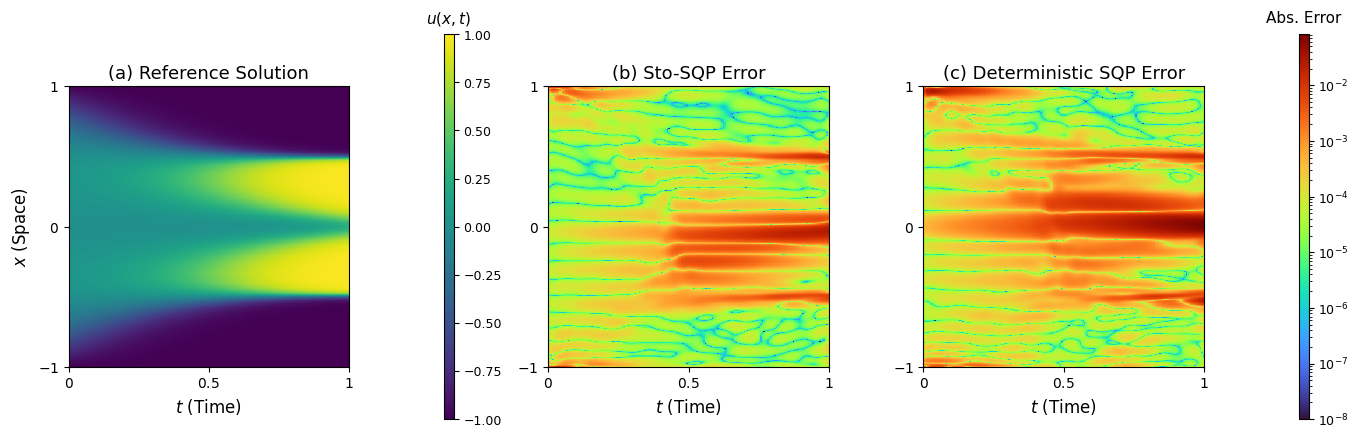

In [1]:
import os
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# ============================================================
# USER SETTINGS
# ============================================================

REF_PATH = "../1/allen_cahn_python.mat"

DET_SQP_PATH = "../1/allen_cahn_stosqp_final_1.npy"
STO_SQP_PATH = "../1/allen_cahn_stosqp_final_deter.npy"

SAVE_PREFIX = "allen_cahn_reference_plus_sto_det_errors"

X_MIN, X_MAX = -1.0, 1.0
T_MIN, T_MAX =  0.0, 1.0

SQP_LAYER_SIZES = [2, 30, 30, 30, 1]
SQP_ACTIVATION = "tanh"

NORMALIZE_INPUT = True

ERR_FLOOR = 1e-8
FIG_DPI = 300


# ============================================================
# HELPERS
# ============================================================

def check_file(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")
    return path


def load_reference_mat(path):
    mat = scipy.io.loadmat(path)

    if "x" not in mat or "t" not in mat or "usol" not in mat:
        raise KeyError("Reference .mat must contain keys: x, t, usol")

    x = np.asarray(mat["x"]).squeeze().astype(np.float64)
    t = np.asarray(mat["t"]).squeeze().astype(np.float64)
    u_ref = np.asarray(mat["usol"]).astype(np.float64)

    if u_ref.shape[0] != len(t) and u_ref.shape[1] == len(t):
        u_ref = u_ref.T

    if u_ref.shape != (len(t), len(x)):
        raise ValueError(
            f"Reference usol shape mismatch. "
            f"Expected {(len(t), len(x))}, got {u_ref.shape}"
        )

    return x, t, u_ref


def normalize_xt(X):
    x = X[:, 0:1]
    t = X[:, 1:2]

    x_n = 2.0 * (x - X_MIN) / (X_MAX - X_MIN) - 1.0
    t_n = 2.0 * (t - T_MIN) / (T_MAX - T_MIN) - 1.0

    return np.concatenate([x_n, t_n], axis=1)


def activate(z, name):
    if name == "tanh":
        return np.tanh(z)
    elif name == "silu":
        return z / (1.0 + np.exp(-z))
    elif name == "gelu":
        return 0.5 * z * (
            1.0 + np.tanh(np.sqrt(2.0 / np.pi) * (z + 0.044715 * z ** 3))
        )
    else:
        raise ValueError(f"Unsupported activation: {name}")


def unflatten_theta(theta, layer_sizes):
    theta = np.asarray(theta, dtype=np.float64).reshape(-1)
    params = []
    idx = 0

    for m, n in zip(layer_sizes[:-1], layer_sizes[1:]):
        w_size = m * n
        b_size = n

        W = theta[idx:idx + w_size].reshape(m, n)
        idx += w_size

        b = theta[idx:idx + b_size].reshape(1, n)
        idx += b_size

        params.append((W, b))

    if idx != len(theta):
        raise ValueError(
            f"Did not consume all theta entries: used {idx}, total {len(theta)}.\n"
            f"Layer sizes = {layer_sizes}"
        )

    return params


def mlp_predict(theta, layer_sizes, X, activation="tanh", normalize_input=True):
    params = unflatten_theta(theta, layer_sizes)

    H = normalize_xt(X) if normalize_input else X.copy()

    for i, (W, b) in enumerate(params):
        H = H @ W + b
        if i < len(params) - 1:
            H = activate(H, activation)

    return H[:, 0]


def predict_on_grid(theta, layer_sizes, x, t, activation="tanh", normalize_input=True):
    XX, TT = np.meshgrid(x, t, indexing="xy")

    X_eval = np.stack(
        [XX.reshape(-1), TT.reshape(-1)],
        axis=1,
    )

    u_pred = mlp_predict(
        theta=theta,
        layer_sizes=layer_sizes,
        X=X_eval,
        activation=activation,
        normalize_input=normalize_input,
    )

    return u_pred.reshape(len(t), len(x))


def mse(a, b):
    return float(np.mean((a - b) ** 2))


def rel_l2(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2) / (np.mean(b ** 2) + 1e-30)))


# ============================================================
# MAIN
# ============================================================

def main():
    check_file(REF_PATH)
    check_file(STO_SQP_PATH)
    check_file(DET_SQP_PATH)

    x, t, u_ref = load_reference_mat(REF_PATH)

    print("Loaded reference:")
    print("  x shape =", x.shape)
    print("  t shape =", t.shape)
    print("  u_ref shape =", u_ref.shape)
    print("  u_ref min/max =", np.min(u_ref), np.max(u_ref))

    theta_sto = np.asarray(np.load(STO_SQP_PATH, allow_pickle=True), dtype=np.float64).reshape(-1)
    theta_det = np.asarray(np.load(DET_SQP_PATH, allow_pickle=True), dtype=np.float64).reshape(-1)

    print("\nParameter counts:")
    print("  Sto-SQP theta size =", theta_sto.size)
    print("  Det-SQP theta size =", theta_det.size)

    u_sto = predict_on_grid(
        theta_sto, SQP_LAYER_SIZES, x, t,
        activation=SQP_ACTIVATION,
        normalize_input=NORMALIZE_INPUT,
    )

    u_det = predict_on_grid(
        theta_det, SQP_LAYER_SIZES, x, t,
        activation=SQP_ACTIVATION,
        normalize_input=NORMALIZE_INPUT,
    )

    err_sto = np.abs(u_sto - u_ref)
    err_det = np.abs(u_det - u_ref)

    print("\nFull-grid metrics:")
    for name, upred in [
        ("Sto-SQP", u_sto),
        ("Deterministic SQP", u_det),
    ]:
        print(
            f"{name:<20s} MSE = {mse(upred, u_ref):.6e}   "
            f"relL2 = {rel_l2(upred, u_ref):.6e}"
        )

    # --------------------------------------------------------
    # Color setup
    # --------------------------------------------------------
    ref_cmap = "viridis"    # reference solution colormap
    err_cmap = "turbo"      # error heatmap colormap

    vabs_ref = np.max(np.abs(u_ref))
    ref_vmin = -vabs_ref
    ref_vmax =  vabs_ref

    all_err = np.concatenate([
        err_sto.ravel(),
        err_det.ravel(),
    ])

    err_vmax = max(float(np.max(all_err)), ERR_FLOOR * 10.0)

    print("\nError color scale:")
    print("  vmin =", ERR_FLOOR)
    print("  vmax =", err_vmax)

    err_sto_plot = np.maximum(err_sto, ERR_FLOOR)
    err_det_plot = np.maximum(err_det, ERR_FLOOR)

    err_norm = LogNorm(vmin=ERR_FLOOR, vmax=err_vmax)
    extent = [t[0], t[-1], x[0], x[-1]]

    # --------------------------------------------------------
    # Figure layout: reference + Sto-SQP error + deterministic SQP error
    # --------------------------------------------------------
    fig = plt.figure(figsize=(16, 5.0))

    gs = fig.add_gridspec(
        1,
        5,
        width_ratios=[1.0, 0.035, 1.0, 1.0, 0.035],
        wspace=0.55,
    )

    ax_ref = fig.add_subplot(gs[0, 0])
    cax_ref = fig.add_subplot(gs[0, 1])

    ax_sto = fig.add_subplot(gs[0, 2])
    ax_det = fig.add_subplot(gs[0, 3])

    cax_err = fig.add_subplot(gs[0, 4])

    im_ref = ax_ref.imshow(
        u_ref.T,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap=ref_cmap,
        vmin=ref_vmin,
        vmax=ref_vmax,
        interpolation="nearest",
    )

    cb_ref = fig.colorbar(im_ref, cax=cax_ref)
    cb_ref.ax.set_title(r"$u(x,t)$", fontsize=11, pad=8)
    cb_ref.ax.tick_params(labelsize=9)

    ax_ref.set_title("(a) Reference Solution", fontsize=13)

    im_sto = ax_sto.imshow(
        err_sto_plot.T,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap=err_cmap,
        norm=err_norm,
        interpolation="nearest",
    )
    ax_sto.set_title("(b) Sto-SQP Error", fontsize=13)

    im_det = ax_det.imshow(
        err_det_plot.T,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap=err_cmap,
        norm=err_norm,
        interpolation="nearest",
    )
    ax_det.set_title("(c) Deterministic SQP Error", fontsize=13)

    cb_err = fig.colorbar(im_det, cax=cax_err)
    cb_err.ax.set_title("Abs. Error", fontsize=11, pad=8)
    cb_err.ax.tick_params(labelsize=9)

    # --------------------------------------------------------
    # Axis labels / tick labels
    # --------------------------------------------------------
    all_axes = [ax_ref, ax_sto, ax_det]

    for ax in all_axes:
        ax.set_xlabel(r"$t$ (Time)", fontsize=12)

        ax.set_xlim(float(t[0]), float(t[-1]))
        ax.set_ylim(float(x[0]), float(x[-1]))

        ax.set_xticks([0.0, 0.5, 1.0])
        ax.set_xticklabels([r"$0$", r"$0.5$", r"$1$"])

        ax.set_yticks([-1.0, 0.0, 1.0])
        ax.set_yticklabels([r"$-1$", r"$0$", r"$1$"])

        ax.tick_params(labelsize=10)
        ax.set_box_aspect(1)

    ax_ref.set_ylabel(r"$x$ (Space)", fontsize=12)

    for ax in [ax_sto, ax_det]:
        ax.set_ylabel("")

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------
    fig.savefig(f"{SAVE_PREFIX}.png", dpi=FIG_DPI, bbox_inches="tight")
    fig.savefig(f"{SAVE_PREFIX}.pdf", bbox_inches="tight")

    print(f"\nSaved figure -> {SAVE_PREFIX}.png")
    print(f"Saved figure -> {SAVE_PREFIX}.pdf")

    plt.show()


if __name__ == "__main__":
    main()


Transport reference data: using ../1/advection_c40_data.npz
Reference loaded:
  x: (256,) range: 0.0 to 6.283185307179586
  t: (600,) range: 0.0 to 1.0
  u_ref: (600, 256)
  u_ref min/max: -0.9999999956768499 0.999999999999663
  c: 40.0
Sto-SQP: using ../1/theta_transport_c60_stosqp_fixed_damp.npy
Sto-SQP: loaded ../1/theta_transport_c60_stosqp_fixed_damp.npy, theta size = 1981
Deterministic SQP: using ../1/theta_transport_c60_stosqp_fixed_damp.npy
Deterministic SQP: loaded ../1/theta_transport_c60_stosqp_fixed_damp.npy, theta size = 1981

Parameter counts:
  Sto-SQP theta size = 1981
  Det-SQP theta size = 1981

Full-grid metrics:
Sto-SQP              MSE = 2.672717e-07   relL2 = 7.311081e-04
Deterministic SQP    MSE = 2.672717e-07   relL2 = 7.311081e-04

Error color scale:
  vmin = 1e-08
  actual Sto/Det vmax = 0.0013169333848996878
  plotted vmax = 1.0

Saved figure -> transport_reference_plus_sto_det_errors.png
Saved figure -> transport_reference_plus_sto_det_errors.pdf


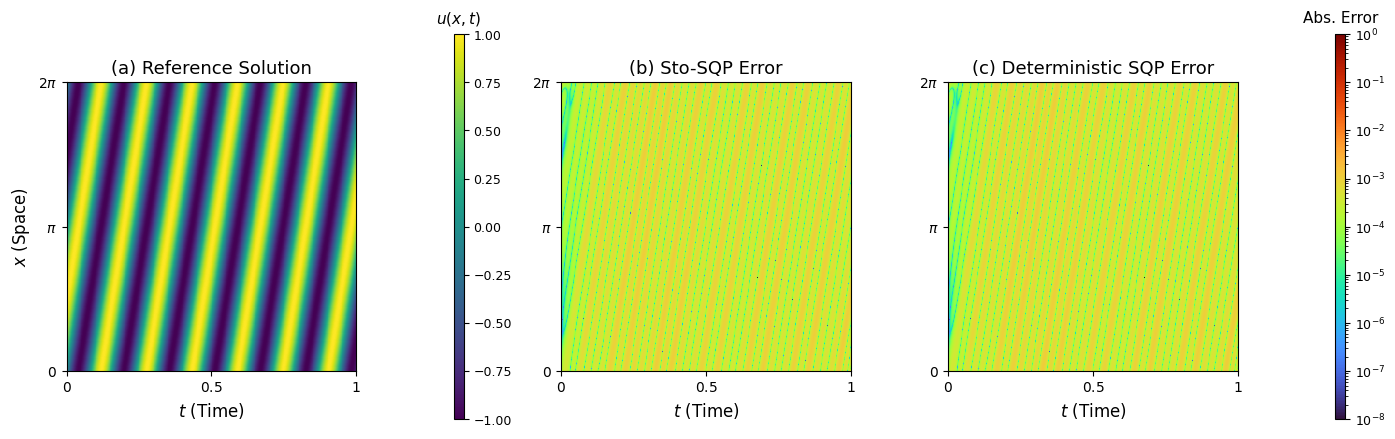

In [5]:
# ============================================================
# Transport heatmaps: Reference + Sto-SQP error + Deterministic SQP error
# ALM and Adam heatmaps removed
# ============================================================

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# ============================================================
# USER SETTINGS
# ============================================================

# Run this from:
#   main/heatmaps/

REF_CANDIDATES = [
    "../1/advection_c40_data.npz",
    "../advection_c40_data.npz",
    "../1/advection_c60_data.npz",   # filename may still say c60, but data may be c=40
    "../advection_c60_data.npz",
    "../1/advection_wave_data.npz",
    "../advection_wave_data.npz",
]

# Sto-SQP
STO_SQP_CANDIDATES = [
    "../1/theta_transport_c60_stosqp_fixed_damp.npy",
    "../theta_transport_c60_stosqp_fixed_damp.npy",
    "../1/theta_transport_c40_stosqp_jitter.npy",
    "../theta_transport_c40_stosqp_jitter.npy",
    "../1/theta_transport_stosqp_c60_jitter1e-5.npy",
    "../theta_transport_stosqp_c60_jitter1e-5.npy",
]

# Deterministic SQP
# Edit this list if your deterministic transport theta uses a different filename.
DET_SQP_CANDIDATES = [
  "../1/theta_transport_c60_stosqp_fixed_damp.npy",
]

SAVE_PREFIX = "transport_reference_plus_sto_det_errors"

# Domain
T_FINAL = 1.0
L_DOMAIN = 2.0 * np.pi
C_ADV = 40.0

# Architecture for both SQP models
SQP_LAYER_SIZES = [2, 30, 30, 30, 1]
SQP_ACTIVATION = "tanh"

NORMALIZE_INPUT = True

# Plot style
REF_CMAP = "viridis"
ERR_CMAP = "turbo"

ERR_FLOOR = 1e-8

# Keep the same log-scale range as the previous 4-panel transport plot.
# This avoids making Sto-SQP/Det-SQP look artificially hot after removing
# ALM and Adam from the displayed heatmaps.
# Set to None if you want the colorbar to auto-scale only to Sto-SQP/Det-SQP.
ERR_VMAX_FIXED = 1.0

FIG_DPI = 300


# ============================================================
# FILE HELPERS
# ============================================================

def _expand_candidate(candidate):
    """Return existing paths for exact or wildcard candidate strings."""
    candidate_path = Path(candidate)

    # Exact path
    if not any(ch in str(candidate_path) for ch in "*?[]"):
        return [candidate_path] if candidate_path.exists() else []

    # Wildcard path
    parent = candidate_path.parent if str(candidate_path.parent) else Path(".")
    pattern = candidate_path.name
    if not parent.exists():
        return []

    return sorted(p for p in parent.glob(pattern) if p.is_file())


def find_existing_file(candidates, name):
    for candidate in candidates:
        matches = _expand_candidate(candidate)
        if matches:
            path = matches[0]
            print(f"{name}: using {path}")
            return str(path)

    raise FileNotFoundError(
        f"Could not find {name}. Tried:\n" + "\n".join(candidates)
    )


def load_theta(candidates, name):
    path = find_existing_file(candidates, name)
    theta = np.load(path, allow_pickle=True)
    theta = np.asarray(theta, dtype=np.float64).reshape(-1)
    print(f"{name}: loaded {path}, theta size = {theta.size}")
    return path, theta


# ============================================================
# REFERENCE DATA
# ============================================================

def generate_transport_dataset(T=T_FINAL, L=L_DOMAIN, c=C_ADV, n_t=600, n_x=256):
    t = np.linspace(0.0, T, n_t)
    x = np.linspace(0.0, L, n_x)
    TT, XX = np.meshgrid(t, x, indexing="ij")
    u_ref = np.sin((XX - c * TT) % L)
    return x, t, u_ref


def load_reference():
    try:
        path = find_existing_file(REF_CANDIDATES, "Transport reference data")
    except FileNotFoundError:
        print("No reference file found. Generating exact transport reference data.")
        return generate_transport_dataset()

    data = np.load(path, allow_pickle=True)

    if "u_ref" in data:
        u_ref = np.asarray(data["u_ref"], dtype=np.float64)
    elif "usol" in data:
        u_ref = np.asarray(data["usol"], dtype=np.float64)
    else:
        raise KeyError("Reference npz must contain 'u_ref' or 'usol'.")

    if "x_star" in data:
        x = np.asarray(data["x_star"], dtype=np.float64).squeeze()
    elif "x" in data:
        x = np.asarray(data["x"], dtype=np.float64).squeeze()
    else:
        raise KeyError("Reference npz must contain 'x_star' or 'x'.")

    if "t_star" in data:
        t = np.asarray(data["t_star"], dtype=np.float64).squeeze()
    elif "t" in data:
        t = np.asarray(data["t"], dtype=np.float64).squeeze()
    else:
        raise KeyError("Reference npz must contain 't_star' or 't'.")

    # Ensure shape is (nt, nx)
    if u_ref.shape == (len(x), len(t)):
        u_ref = u_ref.T

    if u_ref.shape != (len(t), len(x)):
        raise ValueError(
            f"Reference shape mismatch: u_ref.shape={u_ref.shape}, "
            f"expected {(len(t), len(x))}"
        )

    print("Reference loaded:")
    print("  x:", x.shape, "range:", float(x[0]), "to", float(x[-1]))
    print("  t:", t.shape, "range:", float(t[0]), "to", float(t[-1]))
    print("  u_ref:", u_ref.shape)
    print("  u_ref min/max:", float(np.min(u_ref)), float(np.max(u_ref)))

    if "c" in data:
        print("  c:", float(np.asarray(data["c"]).squeeze()))

    return x, t, u_ref


# ============================================================
# MLP HELPERS
# ============================================================

def normalize_xt(X):
    x = X[:, 0:1]
    t = X[:, 1:2]

    x_n = 2.0 * x / L_DOMAIN - 1.0
    t_n = 2.0 * t / T_FINAL - 1.0

    return np.concatenate([x_n, t_n], axis=1)


def activate(z, name):
    if name == "tanh":
        return np.tanh(z)
    elif name == "silu":
        return z / (1.0 + np.exp(-z))
    elif name == "relu":
        return np.maximum(z, 0.0)
    elif name == "gelu":
        return 0.5 * z * (
            1.0 + np.tanh(np.sqrt(2.0 / np.pi) * (z + 0.044715 * z ** 3))
        )
    else:
        raise ValueError(f"Unsupported activation: {name}")


def unflatten_theta(theta, layer_sizes):
    theta = np.asarray(theta, dtype=np.float64).reshape(-1)
    params = []
    idx = 0

    for m, n in zip(layer_sizes[:-1], layer_sizes[1:]):
        w_size = m * n
        b_size = n

        W = theta[idx:idx + w_size].reshape(m, n)
        idx += w_size

        b = theta[idx:idx + b_size].reshape(1, n)
        idx += b_size

        params.append((W, b))

    if idx != theta.size:
        raise ValueError(
            f"Did not consume all theta entries: used {idx}, total {theta.size}.\n"
            f"Layer sizes = {layer_sizes}"
        )

    return params


def mlp_predict(theta, layer_sizes, X, activation="tanh", normalize_input=True):
    params = unflatten_theta(theta, layer_sizes)

    H = normalize_xt(X) if normalize_input else X.copy()

    for i, (W, b) in enumerate(params):
        H = H @ W + b
        if i < len(params) - 1:
            H = activate(H, activation)

    return H[:, 0]


def predict_on_grid(theta, layer_sizes, x, t, activation="tanh", normalize_input=True):
    TT, XX = np.meshgrid(t, x, indexing="ij")

    X_eval = np.stack(
        [XX.reshape(-1), TT.reshape(-1)],
        axis=1,
    )

    u_pred = mlp_predict(
        theta=theta,
        layer_sizes=layer_sizes,
        X=X_eval,
        activation=activation,
        normalize_input=normalize_input,
    )

    return u_pred.reshape(len(t), len(x))


def mse(a, b):
    return float(np.mean((a - b) ** 2))


def rel_l2(a, b):
    return float(np.linalg.norm(a - b) / (np.linalg.norm(b) + 1e-12))


# ============================================================
# MAIN
# ============================================================

def main():
    # --------------------------------------------------------
    # Load reference and models
    # --------------------------------------------------------
    x, t, u_ref = load_reference()

    sto_path, theta_sto = load_theta(STO_SQP_CANDIDATES, "Sto-SQP")
    det_path, theta_det = load_theta(DET_SQP_CANDIDATES, "Deterministic SQP")

    print("\nParameter counts:")
    print("  Sto-SQP theta size =", theta_sto.size)
    print("  Det-SQP theta size =", theta_det.size)

    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------
    u_sto = predict_on_grid(
        theta_sto,
        SQP_LAYER_SIZES,
        x,
        t,
        activation=SQP_ACTIVATION,
        normalize_input=NORMALIZE_INPUT,
    )

    u_det = predict_on_grid(
        theta_det,
        SQP_LAYER_SIZES,
        x,
        t,
        activation=SQP_ACTIVATION,
        normalize_input=NORMALIZE_INPUT,
    )

    # --------------------------------------------------------
    # Errors
    # --------------------------------------------------------
    err_sto = np.abs(u_sto - u_ref)
    err_det = np.abs(u_det - u_ref)

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------
    print("\nFull-grid metrics:")
    for name, upred in [
        ("Sto-SQP", u_sto),
        ("Deterministic SQP", u_det),
    ]:
        print(
            f"{name:<20s} MSE = {mse(upred, u_ref):.6e}   "
            f"relL2 = {rel_l2(upred, u_ref):.6e}"
        )

    # --------------------------------------------------------
    # Color scales
    # --------------------------------------------------------
    ref_vabs = float(np.max(np.abs(u_ref)))
    ref_vmin = -ref_vabs
    ref_vmax = ref_vabs

    all_err = np.concatenate([
        err_sto.ravel(),
        err_det.ravel(),
    ])

    actual_err_vmax = max(float(np.max(all_err)), ERR_FLOOR * 10.0)

    if ERR_VMAX_FIXED is None:
        err_vmax = actual_err_vmax
    else:
        err_vmax = float(ERR_VMAX_FIXED)
        if err_vmax <= ERR_FLOOR:
            raise ValueError(
                f"ERR_VMAX_FIXED must be larger than ERR_FLOOR. "
                f"Got ERR_VMAX_FIXED={ERR_VMAX_FIXED}, ERR_FLOOR={ERR_FLOOR}."
            )

    print("\nError color scale:")
    print("  vmin =", ERR_FLOOR)
    print("  actual Sto/Det vmax =", actual_err_vmax)
    print("  plotted vmax =", err_vmax)

    err_norm = LogNorm(vmin=ERR_FLOOR, vmax=err_vmax)

    err_sto_plot = np.maximum(err_sto, ERR_FLOOR)
    err_det_plot = np.maximum(err_det, ERR_FLOOR)

    extent = [float(t[0]), float(t[-1]), float(x[0]), float(x[-1])]

    # --------------------------------------------------------
    # Figure layout: Reference + Sto-SQP error + Deterministic SQP error
    # --------------------------------------------------------
    fig = plt.figure(figsize=(16.5, 5.0))

    gs = fig.add_gridspec(
        1,
        5,
        width_ratios=[1.0, 0.035, 1.0, 1.0, 0.035],
        wspace=0.55,
    )

    ax_ref = fig.add_subplot(gs[0, 0])
    cax_ref = fig.add_subplot(gs[0, 1])

    ax_sto = fig.add_subplot(gs[0, 2])
    ax_det = fig.add_subplot(gs[0, 3])

    cax_err = fig.add_subplot(gs[0, 4])

    # Reference
    im_ref = ax_ref.imshow(
        u_ref.T,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap=REF_CMAP,
        vmin=ref_vmin,
        vmax=ref_vmax,
        interpolation="nearest",
    )

    cb_ref = fig.colorbar(im_ref, cax=cax_ref)
    cb_ref.ax.set_title(r"$u(x,t)$", fontsize=11, pad=8)
    cb_ref.ax.tick_params(labelsize=9)

    ax_ref.set_title("(a) Reference Solution", fontsize=13)

    # Sto-SQP error
    im_sto = ax_sto.imshow(
        err_sto_plot.T,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap=ERR_CMAP,
        norm=err_norm,
        interpolation="nearest",
    )
    ax_sto.set_title("(b) Sto-SQP Error", fontsize=13)

    # Deterministic SQP error
    im_det = ax_det.imshow(
        err_det_plot.T,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap=ERR_CMAP,
        norm=err_norm,
        interpolation="nearest",
    )
    ax_det.set_title("(c) Deterministic SQP Error", fontsize=13)

    cb_err = fig.colorbar(im_det, cax=cax_err)
    cb_err.ax.set_title("Abs. Error", fontsize=11, pad=8)
    cb_err.ax.tick_params(labelsize=9)

    # --------------------------------------------------------
    # Axis labels
    # --------------------------------------------------------
    all_axes = [ax_ref, ax_sto, ax_det]

    for ax in all_axes:
        ax.set_xlabel(r"$t$ (Time)", fontsize=12)

        ax.set_xlim(float(t[0]), float(t[-1]))
        ax.set_ylim(float(x[0]), float(x[-1]))

        ax.set_xticks([0.0, 0.5, 1.0])
        ax.set_xticklabels([r"$0$", r"$0.5$", r"$1$"])

        ax.set_yticks([0.0, np.pi, 2.0 * np.pi])
        ax.set_yticklabels([r"$0$", r"$\pi$", r"$2\pi$"])

        ax.tick_params(labelsize=10)
        ax.set_box_aspect(1)

    ax_ref.set_ylabel(r"$x$ (Space)", fontsize=12)

    for ax in [ax_sto, ax_det]:
        ax.set_ylabel("")

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------
    fig.savefig(f"{SAVE_PREFIX}.png", dpi=FIG_DPI, bbox_inches="tight", pad_inches=0.02)
    fig.savefig(f"{SAVE_PREFIX}.pdf", bbox_inches="tight", pad_inches=0.02)

    print(f"\nSaved figure -> {SAVE_PREFIX}.png")
    print(f"Saved figure -> {SAVE_PREFIX}.pdf")

    plt.show()


if __name__ == "__main__":
    main()


Burgers reference data: using ../data/burgers.mat
Reference loaded:
  x: (512,) range: -1.0 to 1.0
  t: (201,) range: 0.0 to 1.0
  u_ref: (201, 512)
  u_ref min/max: -0.999995275372036 0.999995275372036
  nu: 0.003183098861837907
Sto-SQP: using ../1/theta_star_pointwise_jitter_1e-5.npz.npy
Sto-SQP: loaded ../1/theta_star_pointwise_jitter_1e-5.npz.npy, theta size=1981
Deterministic SQP: using ../theta_star_pointwise_jitter_1e-5.npz.npy
Deterministic SQP: loaded ../theta_star_pointwise_jitter_1e-5.npz.npy, theta size=1981

Parameter counts:
  Sto-SQP theta size = 1981
  Det-SQP theta size = 1981

================ FULL-GRID METRICS ================
Sto-SQP              MSE = 3.418017e-01, relL2 = 9.529928e-01
Deterministic SQP    MSE = 1.927610e-05, relL2 = 7.156688e-03

Figure metrics:
Sto-SQP              MSE=3.418017e-01, relL2=9.529928e-01
Deterministic SQP    MSE=1.927610e-05, relL2=7.156688e-03

Error color scale:
  vmin = 1e-08
  vmax = 1.0257135852862977

Saved figure -> burgers_r

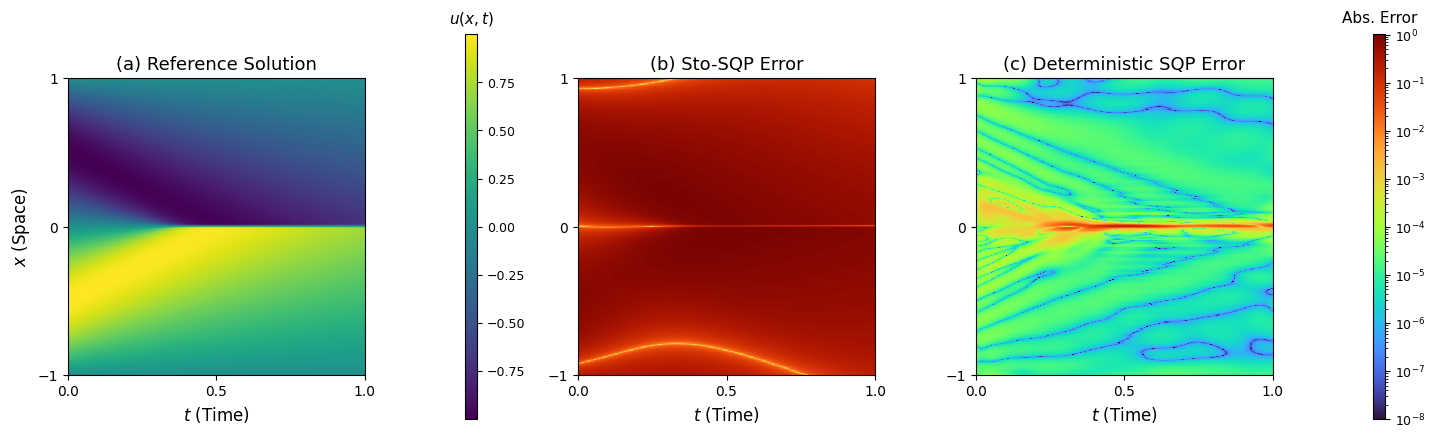

In [4]:
from pathlib import Path

import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# ============================================================
# USER SETTINGS
# ============================================================

# Run this from:
#   main/heatmaps/

# ------------------------------------------------------------
# Reference Burgers data
# ------------------------------------------------------------
REF_CANDIDATES = [
    "data/burgers.mat",
    "../1/data/burgers.mat",
    "../data/burgers.mat",
    "../1/burgers.mat",
    "../burgers.mat",
]

# ------------------------------------------------------------
# Model files
# ------------------------------------------------------------

# Sto-SQP is in folder 1.
# Because np.save("xxx.npz", arr) often creates "xxx.npz.npy",
# include both names.
STO_SQP_CANDIDATES = [
    "../1/theta_star_pointwise_jitter_1e-5.npz.npy",
    "../1/theta_star_pointwise_jitter_1e-5.npy",
    "../1/theta_star_pointwise_jitter_1e-5.npz",
]

# Deterministic SQP is in main folder, not folder 1.
DET_SQP_CANDIDATES = [
    "../theta_star_pointwise_jitter_1e-5.npz.npy",
]

SAVE_PREFIX = "burgers_reference_plus_sto_det_errors"

# ------------------------------------------------------------
# Architecture
# ------------------------------------------------------------
# SQP Burgers from your code style: [2] + [30]*3 + [1]
SQP_LAYER_SIZES = [2, 30, 30, 30, 1]
SQP_ACTIVATION = "tanh"

# IMPORTANT:
# Your Burgers SQP logs said input normalization ON.
# Kept as in your uploaded script. Change to True only if needed.
NORMALIZE_INPUT = False

# Colormap setup
REF_CMAP = "viridis"
ERR_CMAP = "turbo"

# Error log scale
ERR_VMIN = 1e-8

# Keep a fixed upper colorbar scale so the Sto/Det-only figure
# does not get visually over-amplified after ALM/Adam are removed.
ERR_VMAX_MIN = 1.0

FIG_DPI = 300


# ============================================================
# FILE HELPERS
# ============================================================

def find_existing_file(candidates, name):
    for p in candidates:
        if Path(p).exists():
            print(f"{name}: using {p}")
            return p

    raise FileNotFoundError(
        f"Could not find {name}. Tried:\n" + "\n".join(candidates)
    )


def load_theta(candidates, name):
    path = find_existing_file(candidates, name)
    obj = np.load(path, allow_pickle=True)

    # Most of your files are plain theta arrays.
    # If npz, try common keys.
    if hasattr(obj, "files"):
        keys = obj.files
        for key in ["theta", "theta_star", "params_flat"]:
            if key in keys:
                theta = np.asarray(obj[key], dtype=np.float64).reshape(-1)
                print(f"{name}: loaded {path}, key={key}, theta size={theta.size}")
                return path, theta
        raise KeyError(f"{path} is npz with keys {keys}, but no theta key found.")

    theta = np.asarray(obj, dtype=np.float64).reshape(-1)
    print(f"{name}: loaded {path}, theta size={theta.size}")
    return path, theta


# ============================================================
# REFERENCE DATA
# ============================================================

def load_burgers_reference():
    path = find_existing_file(REF_CANDIDATES, "Burgers reference data")
    data = scipy.io.loadmat(path)

    t = np.asarray(data["t"]).squeeze().astype(np.float64)
    x = np.asarray(data["x"]).squeeze().astype(np.float64)
    u_ref = np.asarray(data["usol"], dtype=np.float64)

    if u_ref.shape == (len(x), len(t)):
        u_ref = u_ref.T

    if u_ref.shape != (len(t), len(x)):
        raise ValueError(
            f"Reference shape mismatch: usol.shape={u_ref.shape}, "
            f"expected {(len(t), len(x))}"
        )

    nu = None
    if "nu" in data:
        nu = float(np.asarray(data["nu"]).squeeze())

    print("Reference loaded:")
    print("  x:", x.shape, "range:", float(x[0]), "to", float(x[-1]))
    print("  t:", t.shape, "range:", float(t[0]), "to", float(t[-1]))
    print("  u_ref:", u_ref.shape)
    print("  u_ref min/max:", float(np.min(u_ref)), float(np.max(u_ref)))
    if nu is not None:
        print("  nu:", nu)

    return x, t, u_ref


# ============================================================
# MLP HELPERS
# ============================================================

def normalize_xt(X, x_min, x_max, t_min, t_max):
    x = X[:, 0:1]
    t = X[:, 1:2]

    x_n = 2.0 * (x - x_min) / (x_max - x_min + 1e-30) - 1.0
    t_n = 2.0 * (t - t_min) / (t_max - t_min + 1e-30) - 1.0

    return np.concatenate([x_n, t_n], axis=1)


def activate(z, name):
    if name == "tanh":
        return np.tanh(z)
    elif name == "silu":
        return z / (1.0 + np.exp(-z))
    elif name == "relu":
        return np.maximum(z, 0.0)
    elif name == "gelu":
        return 0.5 * z * (
            1.0 + np.tanh(np.sqrt(2.0 / np.pi) * (z + 0.044715 * z ** 3))
        )
    else:
        raise ValueError(f"Unsupported activation: {name}")


def unflatten_theta(theta, layer_sizes):
    theta = np.asarray(theta, dtype=np.float64).reshape(-1)
    params = []
    idx = 0

    for m, n in zip(layer_sizes[:-1], layer_sizes[1:]):
        w_size = m * n
        b_size = n

        W = theta[idx:idx + w_size].reshape(m, n)
        idx += w_size

        b = theta[idx:idx + b_size].reshape(1, n)
        idx += b_size

        params.append((W, b))

    if idx != theta.size:
        raise ValueError(
            f"Did not consume all theta entries: used {idx}, total {theta.size}.\n"
            f"Layer sizes = {layer_sizes}"
        )

    return params


def mlp_predict(theta, layer_sizes, X, activation, normalize_input, x_min, x_max, t_min, t_max):
    params = unflatten_theta(theta, layer_sizes)

    H = np.asarray(X, dtype=np.float64)

    if normalize_input:
        H = normalize_xt(H, x_min, x_max, t_min, t_max)

    for i, (W, b) in enumerate(params):
        H = H @ W + b
        if i < len(params) - 1:
            H = activate(H, activation)

    return H[:, 0]


def predict_on_grid(theta, layer_sizes, x, t, activation="tanh", normalize_input=True):
    """
    Returns u_pred with shape (nt, nx).
    Input order: [x,t].
    """
    TT, XX = np.meshgrid(t, x, indexing="ij")

    X_eval = np.stack(
        [XX.reshape(-1), TT.reshape(-1)],
        axis=1,
    )

    u_pred = mlp_predict(
        theta=theta,
        layer_sizes=layer_sizes,
        X=X_eval,
        activation=activation,
        normalize_input=normalize_input,
        x_min=float(x[0]),
        x_max=float(x[-1]),
        t_min=float(t[0]),
        t_max=float(t[-1]),
    )

    return u_pred.reshape(len(t), len(x))


def mse(a, b):
    return float(np.mean((a - b) ** 2))


def rel_l2(a, b):
    return float(np.linalg.norm(a - b) / (np.linalg.norm(b) + 1e-12))


# ============================================================
# PLOTTING
# ============================================================

def make_figure(x, t, u_ref, err_dict, metric_dict):
    # --------------------------------------------------------
    # Shared color scales
    # --------------------------------------------------------
    ref_vabs = np.max(np.abs(u_ref))
    ref_vmin = -ref_vabs
    ref_vmax = ref_vabs

    overall_err_max = max(float(np.max(v)) for v in err_dict.values())
    err_vmax = max(ERR_VMAX_MIN, overall_err_max)

    extent = [t[0], t[-1], x[0], x[-1]]

    # --------------------------------------------------------
    # Figure layout
    # [ref] [ref cbar] [sto] [det] [err cbar]
    # --------------------------------------------------------
    fig = plt.figure(figsize=(17, 5.0))

    gs = fig.add_gridspec(
        1,
        5,
        width_ratios=[1.0, 0.04, 1.0, 1.0, 0.04],
        wspace=0.55,
    )

    ax_ref = fig.add_subplot(gs[0, 0])
    cax_ref = fig.add_subplot(gs[0, 1])

    ax_sto = fig.add_subplot(gs[0, 2])
    ax_det = fig.add_subplot(gs[0, 3])

    cax_err = fig.add_subplot(gs[0, 4])

    # --------------------------------------------------------
    # Reference solution
    # --------------------------------------------------------
    im_ref = ax_ref.imshow(
        u_ref.T,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap=REF_CMAP,
        vmin=ref_vmin,
        vmax=ref_vmax,
        interpolation="nearest",
    )

    cb_ref = fig.colorbar(im_ref, cax=cax_ref)
    cb_ref.ax.set_title(r"$u(x,t)$", fontsize=11, pad=8)
    cb_ref.ax.tick_params(labelsize=9)

    ax_ref.set_title("(a) Reference Solution", fontsize=13)

    # --------------------------------------------------------
    # Error heatmaps
    # --------------------------------------------------------
    err_norm = LogNorm(vmin=ERR_VMIN, vmax=err_vmax)

    panels = [
        (ax_sto, "(b) Sto-SQP Error", err_dict["Sto-SQP"]),
        (ax_det, "(c) Deterministic SQP Error", err_dict["Deterministic SQP"]),
    ]

    last_im = None

    for ax, title, err in panels:
        err_plot = np.maximum(err.T, ERR_VMIN)

        last_im = ax.imshow(
            err_plot,
            origin="lower",
            aspect="auto",
            extent=extent,
            cmap=ERR_CMAP,
            norm=err_norm,
            interpolation="nearest",
        )

        ax.set_title(title, fontsize=13)

    cb_err = fig.colorbar(last_im, cax=cax_err)
    cb_err.ax.set_title("Abs. Error", fontsize=11, pad=8)
    cb_err.ax.tick_params(labelsize=9)

    # --------------------------------------------------------
    # Axis formatting
    # --------------------------------------------------------
    all_axes = [ax_ref, ax_sto, ax_det]

    for ax in all_axes:
        ax.set_xlabel(r"$t$ (Time)", fontsize=12)
        ax.set_xlim(t[0], t[-1])
        ax.set_ylim(x[0], x[-1])
        ax.set_xticks([float(t[0]), 0.5 * (float(t[0]) + float(t[-1])), float(t[-1])])
        ax.set_yticks([float(x[0]), 0.0, float(x[-1])])
        ax.tick_params(labelsize=10)
        ax.set_box_aspect(1)

    ax_ref.set_ylabel(r"$x$ (Space)", fontsize=12)

    for ax in [ax_sto, ax_det]:
        ax.set_ylabel("")

    # --------------------------------------------------------
    # Print metrics
    # --------------------------------------------------------
    print("\nFigure metrics:")
    for name in ["Sto-SQP", "Deterministic SQP"]:
        print(
            f"{name:20s} MSE={metric_dict[name]['mse']:.6e}, "
            f"relL2={metric_dict[name]['relL2']:.6e}"
        )

    print("\nError color scale:")
    print("  vmin =", ERR_VMIN)
    print("  vmax =", err_vmax)

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------
    fig.savefig(f"{SAVE_PREFIX}.png", dpi=FIG_DPI, bbox_inches="tight")
    fig.savefig(f"{SAVE_PREFIX}.pdf", bbox_inches="tight")

    print(f"\nSaved figure -> {SAVE_PREFIX}.png")
    print(f"Saved figure -> {SAVE_PREFIX}.pdf")

    plt.show()


# ============================================================
# MAIN
# ============================================================

def main():
    # --------------------------------------------------------
    # Load reference
    # --------------------------------------------------------
    x, t, u_ref = load_burgers_reference()

    # --------------------------------------------------------
    # Load model theta
    # --------------------------------------------------------
    sto_path, theta_sto = load_theta(STO_SQP_CANDIDATES, "Sto-SQP")
    det_path, theta_det = load_theta(DET_SQP_CANDIDATES, "Deterministic SQP")

    print("\nParameter counts:")
    print("  Sto-SQP theta size =", theta_sto.size)
    print("  Det-SQP theta size =", theta_det.size)

    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------
    u_sto = predict_on_grid(
        theta_sto,
        SQP_LAYER_SIZES,
        x,
        t,
        activation=SQP_ACTIVATION,
        normalize_input=NORMALIZE_INPUT,
    )

    u_det = predict_on_grid(
        theta_det,
        SQP_LAYER_SIZES,
        x,
        t,
        activation=SQP_ACTIVATION,
        normalize_input=NORMALIZE_INPUT,
    )

    # --------------------------------------------------------
    # Errors
    # --------------------------------------------------------
    err_sto = np.abs(u_sto - u_ref)
    err_det = np.abs(u_det - u_ref)

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------
    metric_dict = {
        "Sto-SQP": {
            "mse": mse(u_sto, u_ref),
            "relL2": rel_l2(u_sto, u_ref),
        },
        "Deterministic SQP": {
            "mse": mse(u_det, u_ref),
            "relL2": rel_l2(u_det, u_ref),
        },
    }

    print("\n================ FULL-GRID METRICS ================")
    for name, m in metric_dict.items():
        print(f"{name:20s} MSE = {m['mse']:.6e}, relL2 = {m['relL2']:.6e}")

    err_dict = {
        "Sto-SQP": err_sto,
        "Deterministic SQP": err_det,
    }

    make_figure(x, t, u_ref, err_dict, metric_dict)


if __name__ == "__main__":
    main()
